<a href="https://colab.research.google.com/github/garrettspringsted/STAT-7220-Applied-Experimental-Design/blob/main/Garrett_Springsted_HW_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 20, 2026**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Answer #1.** The objective of this experiment is to conclude whether the quiz percentage scores earned by the students are different between the three teaching methods of direct Instruction, Inquiry-based learning, and Collaborative Learning. This is after controlling for the high and low prior knowledge.



**Question 2.** Specify the outcome variable

**Answer #2.** Percentage score earned on Quiz(0-100). This is a quantitative and continuous variable.



**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

**Answer #3.** The independent variable is the teaching method and the blocking factor would be the high or low prior knowledge.
Lurking variables to consider are that some students could be having a bad day.  Do any of the students have learning disabilities that may impact the scores. The testing proctors may be different and their delivery of instruction may vary. Students may be testing on different days or at different times of day. Is the administration done on computers(some students may not be familiar with the program used) or paper.



**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

**Answer #4.** Randomized Block works here because there is a measurable variation via the prior knowledge. This most likely affects the outcome as students with higher prior knowledge would most likely score higher. Blocking  can produce a better idea of the impact of the teaching methods effect.



**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer #5.**
-The Null Hypothesis for this experiment would be where there is no mean difference in test scores between the three teaching methods after controlling for prior knowledge

$$ H_0: \mu_{\text{traditional}} = \mu_{\text{inquiry}} = \mu_{\text{collab}} $$

-The Alternative Hypothesis would be where at least one mean score of the three teaching methods will differ.

$$  \begin{align} H_1: \mu_{\text{traditional}} \neq \mu_{\text{inquiry}} \neq \mu_{\text{collab}}\\
H_1: \mu_{\text{traditional}} \neq \mu_{\text{collab}}\\
H_1:\ \text{At least one } \mu \text{ differs}
\end{align}
$$


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Answer #6.** I would argue that the results from both the summary statistics and the boxplots supports the Alternative Hypothesis. I am able to see that Collaborative Learning is consistently higher in both the summary and visualized in the boxplot while Direct Instruction remains the lowest. It is also important to note that with Higher Prior Knowledge, the score is higher in all three Teaching Methods. It is also apparent from the boxplot that this model supports the alternative hypothesis because there is clear distinction between the means in the teaching groups. It is more evident between those with low Prior Knowledge.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Prior_Knowledge  60 non-null     object 
 1   Teaching_Method  60 non-null     object 
 2   Score            60 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB
None
                                   mean       std
Teaching_Method Prior_Knowledge                  
Collaborative   High             89.390  6.540866
                Low              84.810  7.850254
Direct          High             81.409  6.400299
                Low              73.574  6.028273
Inquiry         High             86.618  5.738629
                Low              77.611  5.153114


Text(0, 0.5, 'Score')

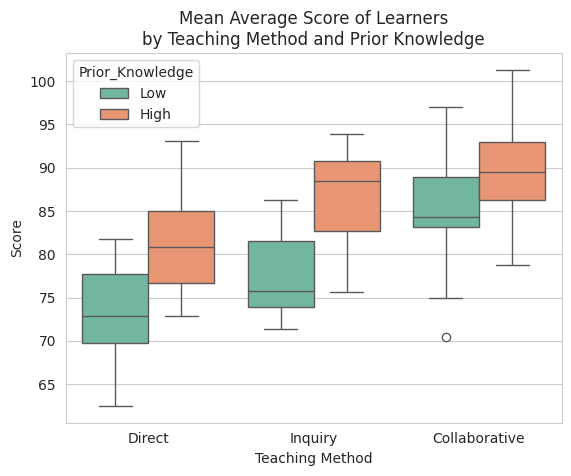

In [ ]:
## Import Appropriate Libraries ##

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Import Data ##

teach = pd.read_excel('Data Science Teaching Method.xlsx')
print(teach.info())

sum_stats = teach.groupby(['Teaching_Method','Prior_Knowledge'])['Score'].agg(['mean','std'])

print(sum_stats)

## Visualize Data ##
sns.set_style("whitegrid")

sns.boxplot(
    data=exercise,
    x='Teaching_Method',
    y='Score',
    hue='Prior_Knowledge',
    palette='Set2'
)
plt.title("Mean Average Score of Learners\nby Teaching Method and Prior Knowledge")
plt.xlabel("Teaching Method")
plt.ylabel("Score")


**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Answer #7. ** After building the ANOVA model I can observe an F-value of 11.632 with a p < 0.05 which may indicate significance. The Q-Q plot of the residuals shows that the residuals closely follow the diagonal line with only slight deviation at the tails. This supports normal distribution of Residuals. For the Shapiro-Wil test our p-value of 0.8794>0.05 so we fail to reject the Null Hypothesis. This confirms that the normality assumption is satisfied.
Both methods support the assumption of normality.


In [ ]:
ex_mod=ols("Score~Teaching_Method+Prior_Knowledge",data=teach).fit()

import scipy.stats as stats
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
ex_tab=sm.stats.anova_lm(ex_mod,typ=3)

ex_tab["Significance"] = np.where(ex_tab["PR(>F)"] < 0.05, "Significant", "Not Significant")

print(ex_tab.loc[["Teaching_Method","Prior_Knowledge"]])

##Shapiro_Wilk Test
shapiro_test =stats.shapiro(ex_residuals)
shapiro_stat=shapiro_test.statistic
shapiro_pvalue=shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue< 0.05:
  print("The residuals are not normally distributed(reject H0).")
else:
    print("The residuals are normally distributed(fail to reject H0).")

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant
Shapiro-Wilk Test Statistic: 0.9893
Shapiro-Wilk Test P-Value: 0.8794
The residuals are normally distributed(fail to reject H0).


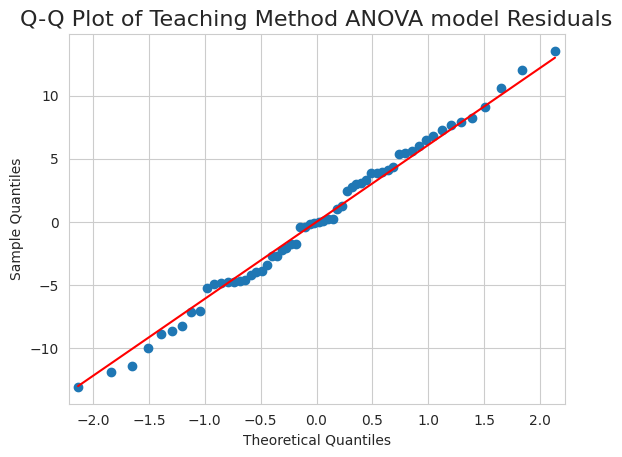

In [ ]:
ex_residuals=ex_mod.resid

sm.qqplot(ex_residuals, line='s')
plt.title("Q-Q Plot of Teaching Method ANOVA model Residuals", fontsize=16)
plt.show()


**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Answer#8.** The points on the residual plot are randomly scattered around Zero. None of the residual exceed 3, -3. There is not an apparent cone or funnel shape with residuals fairly balanced and constant across the fitted values. With the visual method it is assumed that homogenieity of variance is supported.
Looking at the B-P test and that our P-value of 0.522 > 0.05 we again fail to reject the Null Hypothesis so constant variance is assumed.

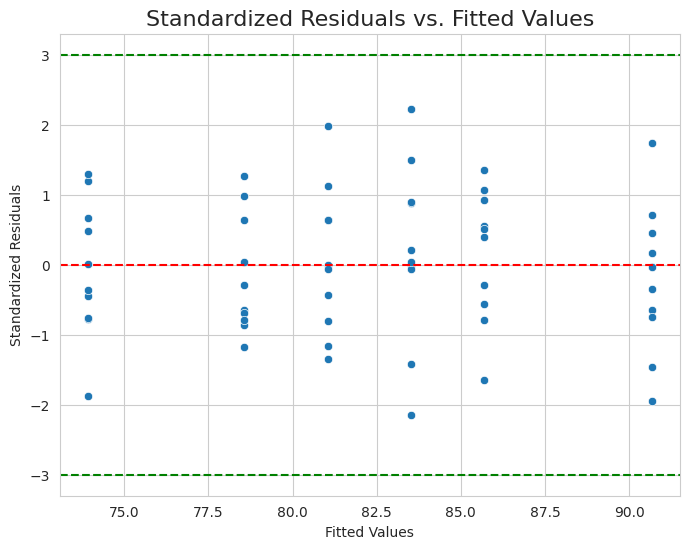

Breusch-Pagan Test F-Statistic: 0.7579
Breusch-Pagan Test P-Value: 0.5224437459616452
No Heteroscedasticity present(fail to reject H0).Constant Variance is assumed


In [ ]:
stan_res=ex_mod.get_influence().resid_studentized_internal
fitted_values=ex_mod.fittedvalues

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=stan_res)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='green', linestyle='--')
plt.axhline(-3, color='green', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values",fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

##B-P Test ##
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test=het_breuschpagan(ex_residuals,ex_mod.model.exog)
f_statistic=bp_test[2]
f_p_value=bp_test[3]

print(f"Breusch-Pagan Test F-Statistic: {f_statistic:.4f}")
print(f"Breusch-Pagan Test P-Value: {f_p_value}")
if f_p_value<0.05:
  print("Heteroscedasticity is present(reject H0).Constant Variance is not assumed")
else:
  print("No Heteroscedasticity present(fail to reject H0).Constant Variance is assumed")


**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Answer #9.** The report shows that our F-values is at 11.632 with a p-value < 0.05 which tells that the data nore strongly supports the alternative hypothesis for the test of the main factor(Teaching_Method). This suggests that the differences in mean test scores between Teaching Method Groups may be statistically meaningful. But since we have more than two groups, the F-test alone cannot tell us which may may be statistically meaningful.

In [ ]:
print(ex_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant



**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Answer #10.** As the data more strongly suported the alternate hypothesis a Tukey test was performed. The Tukey test showed that the only pair that was statiscally different was the relationship between Collaborative and Direct as our p-value < 0.05. The relationship between Collaborative and Inquiry had no statistical difference as well as the relationship between Direct and Inquiry.

Figure(1000x600)
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Collaborative  Direct  -9.6085 0.0003 -15.1184 -4.0986   True
Collaborative Inquiry  -4.9855 0.0838 -10.4954  0.5244  False
       Direct Inquiry    4.623 0.1168  -0.8869 10.1329  False
-------------------------------------------------------------


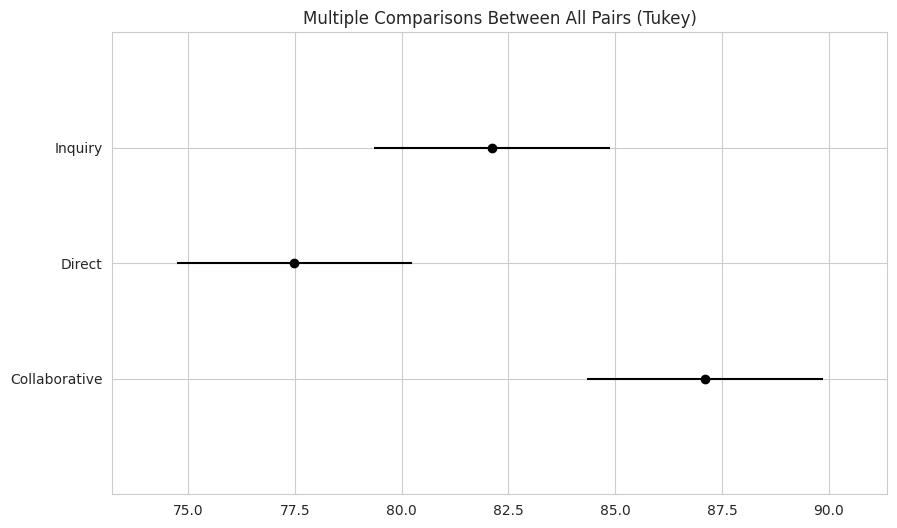

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_result=pairwise_tukeyhsd(endog=teach['Score'],groups=teach['Teaching_Method'],alpha=0.05)
print(tukey_result.plot_simultaneous())
print(tukey_result)


**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.

**Answer #11.** Contextually I can see that after controlling for Prior Knowledge that teaching method does impact the mean of student performance on test scores. The ANOVA model tells me that at least one of the methods is statistically significant but it is not until the Tukey test that I can determine that it was the relationship between Collaborative and Direct that is the most statistically significant. This drove the decision to reject the null hypothesis since at least one of our groups is meaningfully different. I can also see that the blocking factor of high and low prior knowledge is a significant and therefor is valuable in the model.

Some limitations I can brainstorm are that we don't know the base testing scores of the student body being tested for comparison. Are they showing growth at a differnt rate than their peers. When looking at the impact of the teaching method. Is it possible that one method may impact low learners more than others but does not have the same impact on the higher learners. This is also a single test that is being administered. Will the long term effects be different than what is given in this dataset. Will some of the student groups stall in their growth? This snapshot may not be a true representation of growth.

Future directions might include more factors to consider such as study time of participants. Perhaps interaction of how the different teaching methods impact the different levels of Prior Knowledge to observe the overall growth between groups before and after the introduction of the teaching method.

With that said, it appears that Collaborative learning does have the greatest impact when it comes to mean students score. Especially when compared to direct instruction.



**PART 2 INSTRUCTIONS**: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the
semester. Below is a table describing the study design and factors:


| Section \ Day     | Monday | Tuesday | Wednesday | Thursday |
|-------------------|--------|---------|-----------|----------|
| **Morning**       | A      | B       | C         | D        |
| **Early Afternoon** | B      | C       | D         | A        |
| **Mid-Afternoon** | C      | D       | A         | B        |
| **Evening**       | D      | A       | B         | C        |


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the `Online Learning and Engagement.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Answer #1.** The objective of this experiment to to determine if there is a difference in the mean number of logins to the online learning platforms. It is also important to understand that day of week and time of day are not the points of interest.


**Question 2.** Specify the outcome variable

**Answer #2.** The outcome variable is the student engagement on the online learning platforms based on how many logins are recorded for each platform. This will be a numerical variable since we are counting the number of logins.


**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?
The independent variable in this experiment will be the Learning Platforms(A,B,C,D) The blocking factors will be the day of the week and the time of day.

Possible lurking variables could include the study rate for each of the students in a group. The amount of homework assigned to each group. The instructors presenting(or not presenting) the material.The number of other classes the students are taking. Whether the students are part-time or full-time. Do the students work outside of class limiting their time to prepare?


**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.

**Answer #4.** The Latin Square Design works best for this because we have two measurable blocking factors that we want to control for(Day of Week, Time of Day) Each of them also have the same number of levels in the treatment factor(4 days and 4 times)
Completely randomized would not work because it would not control for any factor and would ignore the day and time influence. Randomized block design would not work because it would only allow control for one blocking factor. One of the factors would be uncontrolled reducing accuracy.


**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer #5.**
-The Null Hypothesis for this experiment would be where there is no mean difference in logins across the four learning platforms after controlling for section AND day.

$$ H_0: \mu_{\text{A}} = \mu_{\text{B}} = \mu_{\text{C}}= \mu_{\text{D}} $$

-The Alternative Hypothesis would be where at least one mean engagment of the four learning platforms will differ.

$$  \begin{align} H_1: \mu_{\text{A}} \neq \mu_{\text{B}} \neq \mu_{\text{C}}\neq \mu_{\text{D}}\\
H_1: \mu_{\text{A}} \neq \mu_{\text{C}}\\
H_1: \mu_{\text{A}} \neq \mu_{\text{D}}\\
H_1: \mu_{\text{B}} \neq \mu_{\text{D}}\\
H_1:\ \text{At least one } \mu \text{ differs}
\end{align}
$$


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Answer #6.**
In the Summary statistics I can see a clear distinction in the mean difference between A and C by about 76 logins which is the largest difference. This is followed closely by a clear difference between A and B with about 69 logins. There is also a clear seperation between A and D but not as extreme. There is also a clear difference between platfomr d when compared with B and C by about 40-47 logins.

In the boxplot I can see the distinct differences in engagement between A and B, and A and C. B and C share a good amount of overlap. Platform D also is distinctive in difference, particularly when compared to C.

Seeing that I am able to observe and calculate a substantial mean difference between multiple learning platforms, the results of this descriptive analysis favor the Alternate Hypothesis as at least one platforms mean engagement may differ.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Day         16 non-null     object 
 1   Section     16 non-null     object 
 2   Platform    16 non-null     object 
 3   Engagement  16 non-null     float64
dtypes: float64(1), object(3)
memory usage: 644.0+ bytes
None
               mean        std
Platform                      
A         1408.8475  19.319733
B         1339.7200  39.845434
C         1332.6425  32.288451
D         1379.0225   7.354601


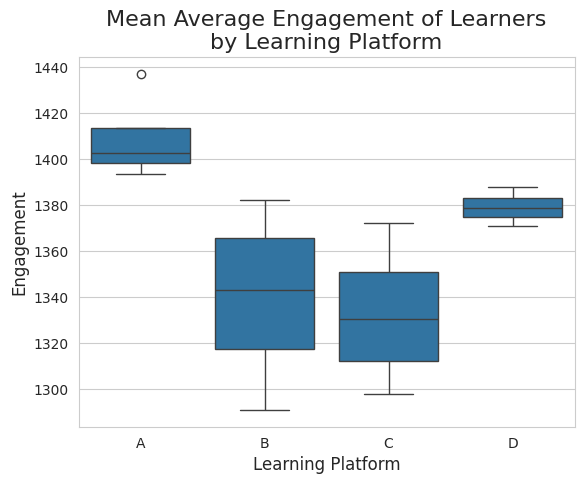

In [6]:
## Import Necessary Packages ##
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Read in Online Learning and Engagement Data ##

learning = pd.read_excel("Online Learning and Engagement.xlsx")

## Data Integrity Check ##

print(learning.info())

## Calcualte Means and Standard Deviations ##

sum_stats = learning.groupby("Platform")["Engagement"].agg(['mean','std'])

print(sum_stats)

##Boxplot##
sns.set_style("whitegrid")

sns.boxplot(
    data=learning,
    x="Platform",
    y='Engagement'
)
plt.title("Mean Average Engagement of Learners\nby Learning Platform",
          fontsize=16)
plt.xlabel("Learning Platform",
           fontsize=12)
plt.ylabel("Engagement",
           fontsize=12)

plt.show()


**Question 7.** Build a three-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Answer #7.** After building the ANOVA table and reviewing the results of the Q-Q plot and Shapiro Wilk test of evaluating the normality of assumption, we can see that the data supports the assuption of normality. I can observe that points on the Q-Q Plot generally follow the path of the line. There is some slight deviation but overall there are not extreme outliers. The p-value of 0.8797 given by the Shapiro Wilk test supports the alternate hypothesis for normality(fail to reject).

                sum_sq   df         F    PR(>F)     Significance
Platform  15221.225819  3.0  7.607701  0.018122      Significant
Day        2774.676069  3.0  1.386807  0.334557  Not Significant
Section    2396.427869  3.0  1.197756  0.387569  Not Significant


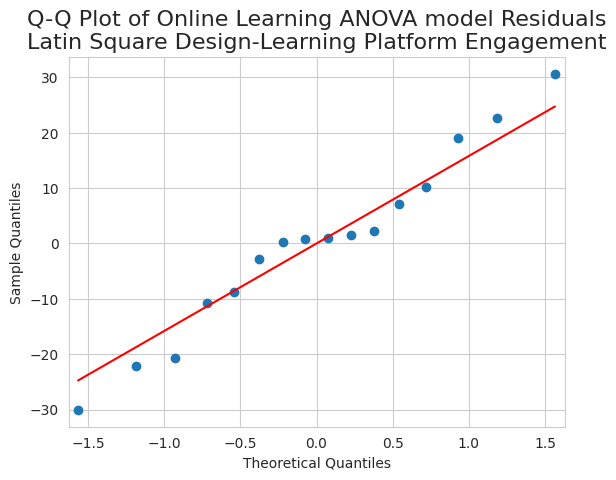

Shapiro-Wilk Test Statistic: 0.9727, p-value: 0.8797
The residuals appear to be normally distributed(fail to reject H0).


In [21]:
## ANOVA Model ##

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

learn_mod=ols("Engagement~Platform+Day+Section",data=learning).fit()
learn_tab=sm.stats.anova_lm(learn_mod,typ=3)
learn_tab["Significance"] = np.where(learn_tab["PR(>F)"] < 0.05, "Significant", "Not Significant")
print(learn_tab.loc[["Platform","Day","Section"]])

## Residuals ##
residuals=learn_mod.resid

sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Online Learning ANOVA model Residuals\nLatin Square Design-Learning Platform Engagement", fontsize=16)
plt.show()

## Shapiro ##
shapiro_test =stats.shapiro(residuals)

shapiro_stat=shapiro_test.statistic
shapiro_pvalue=shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}, p-value: {shapiro_pvalue:.4f}")
if shapiro_pvalue > 0.05:
  print("The residuals appear to be normally distributed(fail to reject H0).")
else:
  print("The residuals do not appear to be normally distributed(reject H0).")


**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Answer #8.** The visual and testing method support the assumption of variance of the residuals. In the scatterplot, the points are all randomly scattered around 0 which implies that 0 could be a resaonable estimate for the mean of the residuals. The spread of the points do not exceed +3/-3. The p-value produced by the het_breuschpagan test of 0.495 fails to reject the null hypothesis(p > 0.05) which supports the assumption of homogeneity of variance.

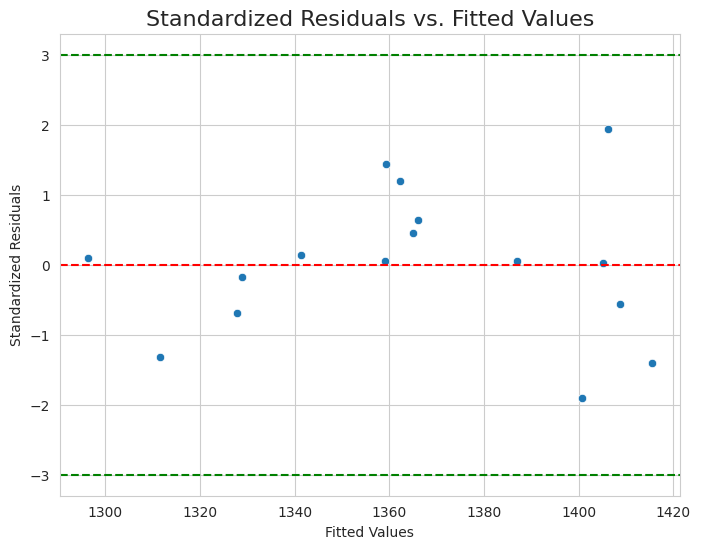

Breusch-Pagan Test F-Statistic: 1.0496
Breusch-Pagan Test P-Value: 0.49513363026521795
No Heteroscedasticity present(fail to reject H0).Constant Variance is assumed


In [17]:
##Constant Variance##
stan_res=learn_mod.get_influence().resid_studentized_internal

## Get fitted values ##
fitted_values=learn_mod.fittedvalues

import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=stan_res)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='green', linestyle='--')
plt.axhline(-3, color='green', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values",fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test=het_breuschpagan(learn_mod.resid,learn_mod.model.exog)
f_statistic=bp_test[2]
f_p_value=bp_test[3]

print(f"Breusch-Pagan Test F-Statistic: {f_statistic:.4f}")
print(f"Breusch-Pagan Test P-Value: {f_p_value}")
if f_p_value<0.05:
  print("Heteroscedasticity is present(reject H0).Constant Variance is not assumed")
else:
  print("No Heteroscedasticity present(fail to reject H0).Constant Variance is assumed")




**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Answer #9.** Only focusing on Platform since Day and Setion are not important to us in this instance. I observe that the p-value of 0.018 more strongly supports that alternative hypothesis especially considering the high F-Value. This suggest that the differences in student engagement we observed between the Learning Platforms may be statistically meaningful.

In [22]:
learn_mod=ols("Engagement~Platform+Day+Section",data=learning).fit()
learn_tab=sm.stats.anova_lm(learn_mod,typ=3)
learn_tab["Significance"] = np.where(learn_tab["PR(>F)"] < 0.05, "Significant", "Not Significant")
print(learn_tab.loc[["Platform","Day","Section"]])


                sum_sq   df         F    PR(>F)     Significance
Platform  15221.225819  3.0  7.607701  0.018122      Significant
Day        2774.676069  3.0  1.386807  0.334557  Not Significant
Section    2396.427869  3.0  1.197756  0.387569  Not Significant



**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Answer #10.** Since the data supports the alternative hypothesis, I performed Tukey's HSD Post-hoc test. Reviewing the table I can observe a couple of important relationships.
A and B have a mean difference of -69.13 and a p-value < 0.05 which indicates significance.
A and C have a mean difference of -76.21 and a p=value < 0.05 which indicates significance.
None of the other comparisons present as statistically significant.
The test shows that we have a least one mean difference and the Tukey test showed that Learning platform A is the primary factor in this difference.

Figure(1000x600)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B -69.1275 0.0186 -127.1688 -11.0862   True
     A      C  -76.205 0.0099 -134.2463 -18.1637   True
     A      D  -29.825 0.4534  -87.8663  28.2163  False
     B      C  -7.0775  0.983  -65.1188  50.9638  False
     B      D  39.3025 0.2375  -18.7388  97.3438  False
     C      D    46.38 0.1359  -11.6613 104.4213  False
-------------------------------------------------------


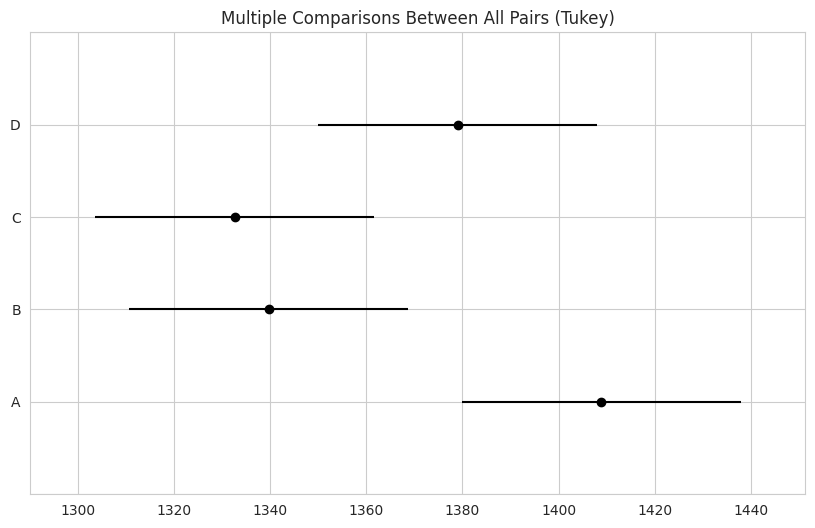

In [23]:
tukey_result=pairwise_tukeyhsd(endog=learning['Engagement'],groups=learning['Platform'],alpha=0.05)
print(tukey_result.plot_simultaneous())
print(tukey_result)


**Question 11.** Write a brief conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.

**Answer #11.** In this experiment the blocking factors included Day and Section and focused on student engagement across the four learning platforms in terms of number of logins. The ANOVA results showed an output of F = 7.6077, p = 0.0181 (p < 0.05) suggesting at least one significant mean difference. Through visualizations and testing we confirmed normality and constant variance rejecting the null hypothesis.
Through Tukey's Test we uncovered that the primary mean difference and factor driving that difference was Learning platform A when compared to Platforms B and C. A did not significantly differ from platform D and the other relationships did not show significance.

Limitations to this experiment may include lack of volume in the study with only one observation per combination of platform and testing group. This limits the power of the results. We also assume that all of these students have the same motivation when it comes to school and have equal access to computers and internet access. Differences in access could meaningfully influence engagement. We did not take into account the students in-person learning engagement in the sense that even though they logged in, how much actual engagement was taking place during the synchronous lessons. Engagement may be a bit more involved than just logging in.

For the future, the experiment should be repeated many times, over multiple semesters. Different content areas could be the focus of repeated experiments. I would expand the sizing of the groups to build a stronger model. I would also suggest breaking down the times to be more specific(i.e. Is morning at 8:00AM or 11:00AM?) focusing the time of day could greatly improve accuracy.